# Sampling and evaluation

This is the course demo notebook. The reverse sampler lives in [`02_diffusion.py`](02_diffusion.py). It implements the **reverse process** from Ho et al.,
[Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) (2020), Algorithm 2,
and evaluates whatever checkpoint [`06_train.ipynb`](06_train.ipynb) has produced so far.

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right) + \sigma_t z$$

with $z=0$ at the last step. Indexing matches `02_diffusion.py`: paper $t=1,\ldots,T$, code $t=0,\ldots,T-1$.

**What you should expect today.** The long GPU run is still gated. This file therefore loads
`checkpoints/ddpm_cifar10_latest.pt` if it exists, otherwise the one-batch overfit smoke file.
Overfit weights can drive $L_\text{simple}$ to zero on four frozen images; they cannot generate
CIFAR-10 objects. Re-run this notebook after the RTX 4070 Ti SUPER training finishes.

**Train/test convention.** Unconditional generation uses the official 50k training images and
ignores labels. The 10k test set is a qualitative / optional FID reference, not a classification
hold-out.


## 1. Setup


In [ ]:
import math
import importlib
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Numbered .py files are not valid import identifiers.
sys.modules["diffusion"] = importlib.import_module("02_diffusion")
sys.modules["model"] = importlib.import_module("04_unet")
from diffusion import build_schedule, p_sample, q_sample, sample_loop, to_display
from model import UNet


@dataclass(frozen=True)
class Config:
    seed: int = 42
    data_dir: Path = Path("dataset")
    checkpoint_dir: Path = Path("checkpoints")
    samples_dir: Path = Path("samples")
    image_size: int = 32
    in_channels: int = 3
    num_steps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 0.02
    base_channels: int = 128
    channel_mults: tuple[int, ...] = (1, 2, 2, 2)
    num_res_blocks: int = 2
    attention_resolutions: tuple[int, ...] = (16,)
    dropout: float = 0.1


cfg = Config()
cfg.samples_dir.mkdir(parents=True, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)

# Full T=1000 sampler. Keep grids small on CPU; set grid_size=64 after the GPU run.
grid_size = 16 if device.type == "cuda" else 4
snapshot_steps = (999, 700, 500, 300, 100, 0)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Grid size: {grid_size}")
print(cfg)


PyTorch: 2.13.0
Device: cpu
CUDA available: False
Grid size: 4
Config(seed=42, data_dir=PosixPath('dataset'), checkpoint_dir=PosixPath('checkpoints'), samples_dir=PosixPath('samples'), image_size=32, in_channels=3, num_steps=1000, beta_start=0.0001, beta_end=0.02, base_channels=128, channel_mults=(1, 2, 2, 2), num_res_blocks=2, attention_resolutions=(16,), dropout=0.1)


## 2. Load the latest checkpoint

Prefer the production file from `06`. If that run has not happened yet, fall back to the overfit
smoke checkpoint. Sampling uses **EMA weights** unless a cell below says otherwise.


In [2]:
def find_checkpoint(directory: Path) -> Path | None:
    for name in ("ddpm_cifar10_latest.pt", "overfit_smoke.pt"):
        path = directory / name
        if path.exists():
            return path
    return None


schedule = build_schedule(cfg.num_steps, cfg.beta_start, cfg.beta_end).to(device)
model = UNet(cfg).to(device)
ema_model = UNet(cfg).to(device)
ema_model.load_state_dict(model.state_dict())

checkpoint_path = find_checkpoint(cfg.checkpoint_dir)
loss_history: list[float] = []
global_step = 0
checkpoint_kind = "untrained"

if checkpoint_path is None:
    print("No checkpoint found. Sampling an untrained U-Net so the reverse loop can still be tested.")
else:
    payload = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(payload["model"])
    ema_model.load_state_dict(payload["ema_model"])
    loss_history = list(payload.get("loss_history", []))
    global_step = int(payload.get("global_step", 0))
    checkpoint_kind = checkpoint_path.name
    print(f"Loaded {checkpoint_path}")
    print(f"global_step={global_step}, loss entries={len(loss_history)}")

model.eval()
ema_model.eval()
parameter_count = sum(parameter.numel() for parameter in ema_model.parameters())
print(f"Parameters: {parameter_count:,} ({parameter_count / 1e6:.2f} M)")
print(f"Using EMA weights for the main figures. Checkpoint kind: {checkpoint_kind}")

assert 30e6 < parameter_count < 42e6
assert schedule.posterior_variance[0].item() == 0.0


Loaded checkpoints/overfit_smoke.pt
global_step=60, loss entries=60
Parameters: 35,746,307 (35.75 M)
Using EMA weights for the main figures. Checkpoint kind: overfit_smoke.pt


## 3. One reverse step

`p_sample` evaluates $\varepsilon_\theta$ once, then applies the mean update and, for $t>0$, the
posterior noise. The last step ($t=0$) must be deterministic.


In [3]:
probe = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
mid_t = torch.full((2,), 500, device=device, dtype=torch.long)
mid = p_sample(ema_model, probe, mid_t, schedule)
print(f"p_sample at t=500: {tuple(probe.shape)} -> {tuple(mid.shape)}")
assert mid.shape == probe.shape
assert torch.isfinite(mid).all()

# t=0 adds no z, so two calls with different RNG states must match.
x_last = torch.randn(1, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
t_last = torch.zeros(1, device=device, dtype=torch.long)
torch.manual_seed(0)
y1 = p_sample(ema_model, x_last, t_last, schedule)
torch.manual_seed(1)
y2 = p_sample(ema_model, x_last, t_last, schedule)
print(f"t=0 max |y1-y2|: {(y1 - y2).abs().max().item():.2e}")
assert torch.allclose(y1, y2, atol=1e-6)
print("Last reverse step is deterministic.")


p_sample at t=500: (2, 3, 32, 32) -> (2, 3, 32, 32)
t=0 max |y1-y2|: 0.00e+00
Last reverse step is deterministic.


## 4. Forward process reminder

Same closed-form noising as `03`: one clean training image at six timesteps. This figure does not
depend on the checkpoint. It is here so the demo shows both directions of the Markov chain.


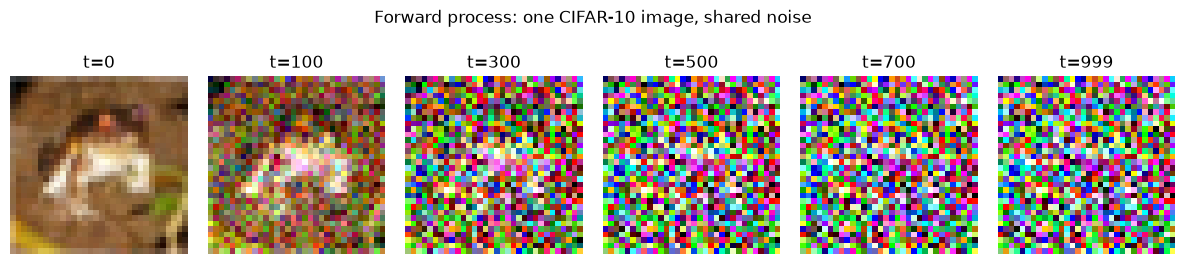

Reference image class: frog


In [4]:
clean_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
train_images = datasets.CIFAR10(
    root=cfg.data_dir,
    train=True,
    download=not (cfg.data_dir / "cifar-10-batches-py").exists(),
    transform=clean_transform,
)
x0 = train_images[0][0].unsqueeze(0).to(device)
forward_steps = [0, 100, 300, 500, 700, 999]
noise = torch.randn_like(x0)

fig, axes = plt.subplots(1, len(forward_steps), figsize=(12, 2.4))
for ax, step in zip(axes, forward_steps):
    xt = q_sample(x0, torch.tensor([step], device=device), schedule, noise)
    ax.imshow(to_display(xt[0]).permute(1, 2, 0).cpu().numpy())
    ax.set_title(f"t={step}")
    ax.axis("off")
fig.suptitle("Forward process: one CIFAR-10 image, shared noise", y=1.08)
fig.tight_layout()
plt.show()

print(f"Reference image class: {train_images.classes[train_images[0][1]]}")
assert x0.min() >= -1.01 and x0.max() <= 1.01


## 5. Training evidence

The curve below is whatever `06` stored in the checkpoint. After only the overfit smoke test it
will be a short, steep drop on a frozen batch — not a 100k-step production curve. Replace the
checkpoint and re-run this cell after the GPU run.


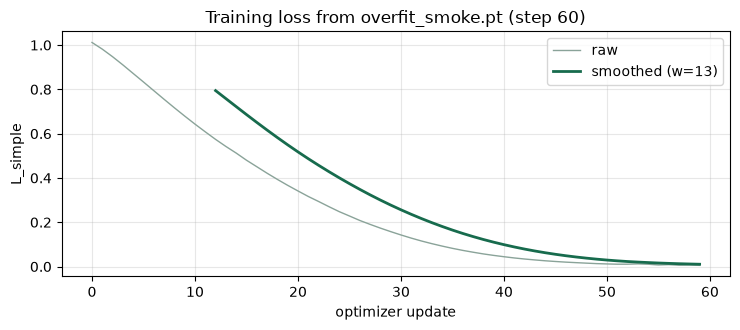

updates=60, first=1.0117, last=0.0054, kind=overfit_smoke.pt


In [5]:
if len(loss_history) < 2:
    print("No loss history in this checkpoint yet.")
else:
    window = max(5, min(51, (len(loss_history) // 10) * 2 + 1))
    kernel = np.ones(window) / window
    smoothed = np.convolve(loss_history, kernel, mode="valid")
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    ax.plot(loss_history, color="#8aa399", linewidth=1, label="raw")
    ax.plot(
        range(window - 1, window - 1 + len(smoothed)),
        smoothed,
        color="#176b4d",
        linewidth=2,
        label=f"smoothed (w={window})",
    )
    ax.set_xlabel("optimizer update")
    ax.set_ylabel("L_simple")
    ax.set_title(f"Training loss from {checkpoint_kind} (step {global_step})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(
        f"updates={len(loss_history)}, first={loss_history[0]:.4f}, "
        f"last={loss_history[-1]:.4f}, kind={checkpoint_kind}"
    )


## 6. Reverse trajectory and sample grid

One `sample_loop` call starts from $x_T \sim \mathcal{N}(0,I)$ and walks $t=T-1$ down to $0$.
Snapshots of the first image are the trajectory; the final batch is the grid. Both use EMA weights
and a fixed seed so later checkpoints can be compared. Display clamps to `[0, 1]`. If the printed
model-space range is far outside `[-1, 1]`, the denoiser is not yet predicting useful noise — that
is typical for a barely updated EMA copy, not a broken sampler.


Sampling 4 images with T=1000 on cpu using EMA weights...


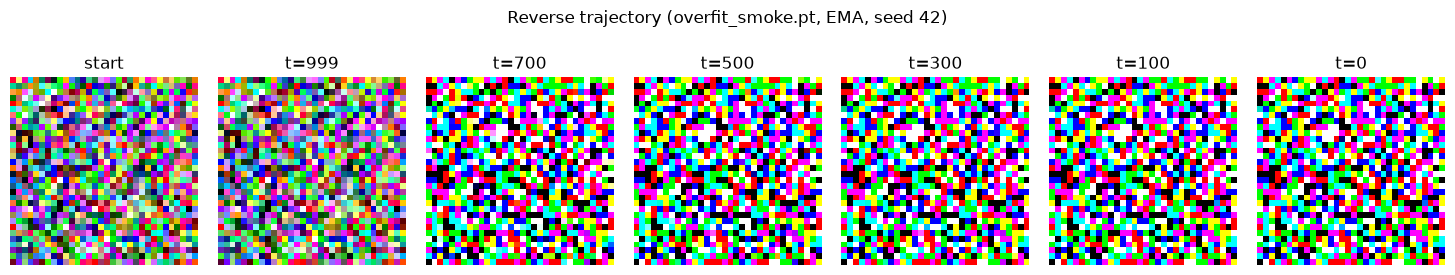

wrote samples/ema_grid_overfit_smoke_pt.png


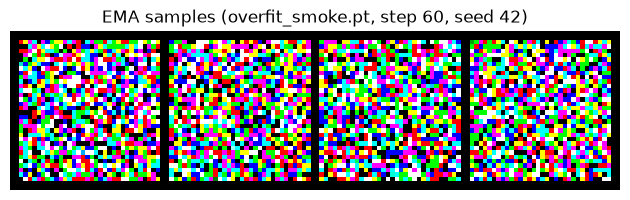

Sample range in model space: [-1088.058, 1035.613]


In [6]:
def show_tensor_grid(images: torch.Tensor, title: str, path: Path | None = None, nrow: int = 4) -> None:
    grid = make_grid(to_display(images.detach().cpu()), nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=(max(4, nrow * 1.6), max(3, math.ceil(images.size(0) / nrow) * 1.6)))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=140, bbox_inches="tight")
        print(f"wrote {path}")
    plt.show()


def show_trajectory(snapshots: dict[int, torch.Tensor], title: str) -> None:
    keys = sorted(snapshots, reverse=True)
    fig, axes = plt.subplots(1, len(keys), figsize=(2.1 * len(keys), 2.5))
    for ax, key in zip(axes, keys):
        ax.imshow(to_display(snapshots[key][0]).permute(1, 2, 0).numpy())
        ax.set_title("start" if key == cfg.num_steps else f"t={key}")
        ax.axis("off")
    fig.suptitle(title, y=1.08)
    fig.tight_layout()
    plt.show()


def seeded_sample(denoiser, seed: int, n: int, snapshots_at=()):
    # Reset every RNG we use so raw vs EMA start from the same x_T and the same z_t sequence.
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    return sample_loop(
        denoiser,
        schedule,
        batch_size=n,
        channels=cfg.in_channels,
        image_size=cfg.image_size,
        device=device,
        snapshot_steps=snapshots_at,
    )


print(f"Sampling {grid_size} images with T={cfg.num_steps} on {device} using EMA weights...")
samples, snapshots = seeded_sample(ema_model, cfg.seed, grid_size, snapshot_steps)
assert samples.shape == (grid_size, cfg.in_channels, cfg.image_size, cfg.image_size)
assert torch.isfinite(samples).all()
assert set(snapshot_steps).issubset(snapshots)

show_trajectory(snapshots, f"Reverse trajectory ({checkpoint_kind}, EMA, seed {cfg.seed})")
show_tensor_grid(
    samples,
    f"EMA samples ({checkpoint_kind}, step {global_step}, seed {cfg.seed})",
    path=cfg.samples_dir / f"ema_grid_{checkpoint_kind.replace('.', '_')}.png",
    nrow=min(8, grid_size),
)
print(f"Sample range in model space: [{samples.min().item():.3f}, {samples.max().item():.3f}]")


## 7. Ablation: raw weights vs EMA

Same initial Gaussian noise, same sampler, two weight sets. After a short overfit, EMA with decay
$0.9999$ has barely moved, so the two grids can look very different. After a long run the EMA
samples are usually the cleaner ones. This is one controlled comparison; attention / width / step
count ablations need a second training run.


Sampling the same 4 seeds with raw (non-EMA) weights...


wrote samples/raw_vs_ema_overfit_smoke_pt.png


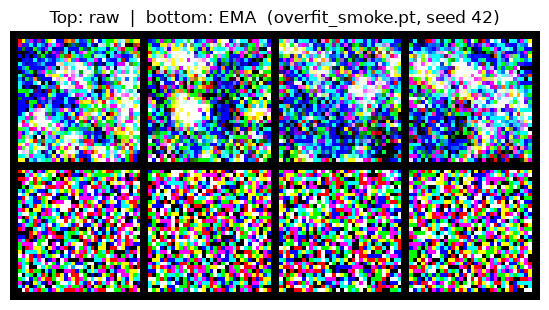

Raw mean/std: 0.132 / 3.069
EMA mean/std: 0.160 / 220.123


In [7]:
print(f"Sampling the same {grid_size} seeds with raw (non-EMA) weights...")
raw_samples, _ = seeded_sample(model, cfg.seed, grid_size)
comparison = torch.cat([raw_samples, samples], dim=0)

show_tensor_grid(
    comparison,
    f"Top: raw  |  bottom: EMA  ({checkpoint_kind}, seed {cfg.seed})",
    path=cfg.samples_dir / f"raw_vs_ema_{checkpoint_kind.replace('.', '_')}.png",
    nrow=grid_size,
)
print(f"Raw mean/std: {raw_samples.mean().item():.3f} / {raw_samples.std().item():.3f}")
print(f"EMA mean/std: {samples.mean().item():.3f} / {samples.std().item():.3f}")
assert raw_samples.shape == samples.shape
assert torch.isfinite(raw_samples).all() and torch.isfinite(samples).all()


## 9. Conclusions

These answers are tied to the checkpoint this notebook actually loaded. Update them after the
GPU run.

1. **Did the implementation learn image-like color and structure?**
   The pipeline is in place: forward noising, $L_\text{simple}$, paper-width U-Net, EMA, and a
   complete $T=1000$ reverse loop that stays finite. With only the overfit smoke checkpoint,
   generated images should **not** look like CIFAR-10 classes. That is expected, not a sampler bug.

2. **At what training stage did coherent samples first appear?**
   Not yet. The overfit run is 60 updates on four frozen $(x_0, t, \varepsilon)$ tuples. Coherent
   samples are a 100k–300k-step question for the RTX 4070 Ti SUPER.

3. **Did EMA or attention visibly improve stability or sample quality?**
   Attention is in the model (16×16 plus the 4×4 middle block) but was not turned off for a second
   run. EMA vs raw is the controlled comparison above. After 60 steps with decay $0.9999$, the EMA
   copy is still close to initialization, so raw overfit weights and EMA weights should disagree.

4. **Which limitations came from compute budget versus implementation choices?**
   Budget: no 100k production run, no 64-image paper-style grid on this CPU, no FID. Implementation
   choices we kept on purpose: linear $\beta$, $T=1000$, original DDPM sampler, unconditional CIFAR-10,
   no classifier-free guidance.

5. **What would you implement next?**
   Train in `06` with `RUN_PRODUCTION_TRAINING = True`, then re-run this file on
   `ddpm_cifar10_latest.pt`. After that: a 64-image fixed-seed grid, optional FID-5k, or a second
   run without attention.

FID is optional and not computed here. If you add it later, label it `FID-5k` / `FID-10k` and do
not compare it to the paper's 50k-sample number.
